### IEEE Std 738 (2023): Transient conductor temperature (Page 32)

This notebook illustrates the use of the TB 601 implementation included in the **Pypacity** library.

---

**PyPacity**

Copyright (c) 2026 Group of Advanced Electro-Technologies (GTEA). Universidad de Cantabria. All rights reserved    
SPDX-License-Identifier: GPL-3.0-only

In [4]:
%load_ext autoreload
%autoreload 2

from pypacity.ieee738 import ieee738
from pypacity.cable import cable
from pypacity.case import case
from pypacity.utils import solar
from datetime import datetime

import matplotlib.pyplot as plt 
import numpy as np

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


 
******************************************************************
*******************************************************************
IEEE 738
*******************************************************************
The angle between wind and conductor is =  90  DEG
Solar heating:   22.443  W/m
Radiation cooling:  55.373  W/m
Convection cooling:  106.975  W/m
 
******************************************************************
*******************************************************************
IEEE 738
*******************************************************************
The angle between wind and conductor is =  90  DEG
Solar heating:   22.443  W/m
Radiation cooling:  82.371  W/m
Convection cooling:  141.82  W/m


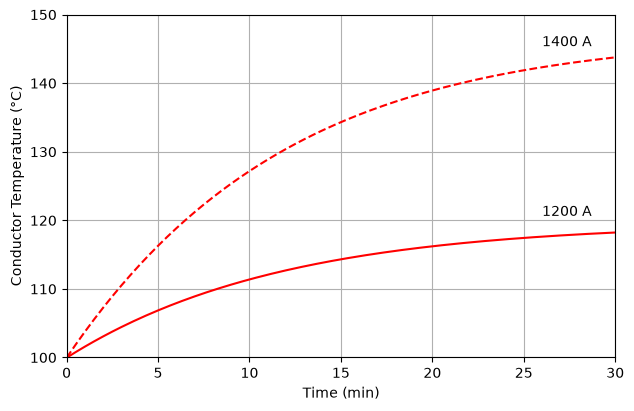

In [5]:

NSELECT = 3
Cable = cable.Cable()
c_db, error = Cable.load_cable_db()
Cable.set_cable(NSELECT, conductor = 'DRAKE')

Case_ss = case.Case()
Case_ss.demo( NSELECT )

Cable.ABSORP = 0.8
Cable.EMISS  = 0.8

Case_ss.CDR_LAT_DEG = 30
Case_ss.CDR_ELEV = 0
Case_ss.beta   = 0
Case_ss.Z1_DEG = 90

dt1 = datetime(2026, 6, 10, 11, 00)
PV1 = solar.SolarGeometry()
Case_ss.SOLAR = 1
Case_ss.SUN_TIME = 11
Case_ss.NDAY = PV1.DatetimetoDayOfYear(dt1) 
Case_ss.Ns = 1.0

Case_ss.DWIND_DEG = 0
Case_ss.TAMB  = 40
Case_ss.VWIND = 0.61

Case_ss.SORM    = 0
Case_ss.TT      = 30*60
Case_ss.DELTIME = 10

fig, ax  = plt.subplots(1,1,constrained_layout=True,figsize=(8,4))

for Ic in [1200,1400]:
    
    Case_ss.XIPRELOAD = 1025
    Case_ss.XISTEP    = Ic
    
    std738 = ieee738.IEEE738()
    std738.set_cable( Cable )
    std738.set_case(  Case_ss  )
    std738.Case1.ATCDR = []
    std738.Case1.TIME  = []
    std738.Debug = 0
    std738.ieee_738()
    std738.output()
    
    get_ls = lambda x: '-' if x == 1200 else '--'
    ax.plot(np.array(std738.Case1.TIME)/60,std738.Case1.ATCDR,'r',ls=get_ls(Ic))
    
    Tdata = 26
    idx = np.argwhere(np.array(std738.Case1.TIME)/60 > Tdata )[0][0]
    ax.text(Tdata ,std738.Case1.ATCDR[idx]+3,f'{Ic} A')

ax.set_yticks(np.arange(100,150+10,10))
ax.set_xticks(np.arange(0,30+5,5))
ax.set_ylim(100,150)
ax.grid();
ax.set_xlim(0,30)
ax.set_box_aspect(1/1.6);
ax.set_xlabel('Time (min)')
ax.set_ylabel('Conductor Temperature (°C)');

plt.savefig(f"images/ieee738_test_transient.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05);